## Banking Customer Analytics: Deposit and Loan Performance Analysis

### Problem Statement:- Develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimise the risk of loosing money while lending to customers.

In [2]:
import sys
sys.executable
%pip install pyodbc sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 3.2 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 3.3 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.6 MB/s  0:00:00

   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   --------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Acer\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import pyodbc
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

In [4]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-86GM60Q\SQLEXPRESS;"
    "DATABASE=banking_case;"
    "Trusted_Connection=yes;"
)

In [5]:
query = "select * from Banking"
df = pd.read_sql(query, conn)
df.head()

,Client_ID,Name,Age,Location_ID,Joined_Bank,Banking_Contact,Nationality,Occupation,Fee_Structure,Loyalty_Classification,...,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1.485829e+06,6.036179e+05,607332.437500,12249.959961,1.134475e+06,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,6.414828e+05,2.295214e+05,344635.156250,61162.308594,2.000526e+06,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1.033402e+06,6.526747e+05,203054.343750,79071.781250,5.481376e+05,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1.048158e+06,1.048158e+06,234685.015625,57513.648438,1.148402e+06,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,4.877825e+05,4.466442e+05,128351.453125,30012.140625,1.674412e+06,0,3,1,2,5


In [6]:
conn.close()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#Understanding the data:-
df.shape

(3000, 25)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client_ID                 3000 non-null   str    
 1   Name                      3000 non-null   str    
 2   Age                       3000 non-null   int64  
 3   Location_ID               3000 non-null   int64  
 4   Joined_Bank               3000 non-null   object 
 5   Banking_Contact           3000 non-null   str    
 6   Nationality               3000 non-null   str    
 7   Occupation                3000 non-null   str    
 8   Fee_Structure             3000 non-null   str    
 9   Loyalty_Classification    3000 non-null   str    
 10  Estimated_Income          3000 non-null   float64
 11  Superannuation_Savings    3000 non-null   float64
 12  Amount_of_Credit_Cards    3000 non-null   int64  
 13  Credit_Card_Balance       3000 non-null   float64
 14  Bank_Loans         

In [9]:
df.describe()

,Age,Location_ID,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,Credit_Card_Balance,Bank_Loans,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034184,25531.599685,1.463667,3176.206944,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529998,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808180,16259.950768,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924033,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480469,1482.030029,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.597656,12513.774902,1.000000,1236.630005,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542236,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.476562,22357.355469,1.000000,2560.804932,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190430,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.300781,35464.741211,2.000000,4522.632690,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.391602,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.250000,75963.898438,3.000000,13991.990234,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.867188,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [10]:
#Converting the Joined_Bank from int to datetime:-
df['Joined_Bank']=pd.to_datetime(df['Joined_Bank'])

In [11]:
df.dtypes

Client_ID                             str
Name                                  str
Age                                 int64
Location_ID                         int64
Joined_Bank                 datetime64[s]
Banking_Contact                       str
Nationality                           str
Occupation                            str
Fee_Structure                         str
Loyalty_Classification                str
Estimated_Income                  float64
Superannuation_Savings            float64
Amount_of_Credit_Cards              int64
Credit_Card_Balance               float64
Bank_Loans                        float64
Bank_Deposits                     float64
Checking_Accounts                 float64
Saving_Accounts                   float64
Foreign_Currency_Account          float64
Business_Lending                  float64
Properties_Owned                    int64
Risk_Weighting                      int64
BRId                                int64
GenderId                          

In [12]:
#Creating a Income_Band from Estimated_Income:-
bins=[0,100000,300000,float('inf')]
labels=['Low','Medium','High']
df['Income_Band']=pd.cut(df['Estimated_Income'],bins=bins,labels=labels,right=False)

<Axes: xlabel='Income_Band'>

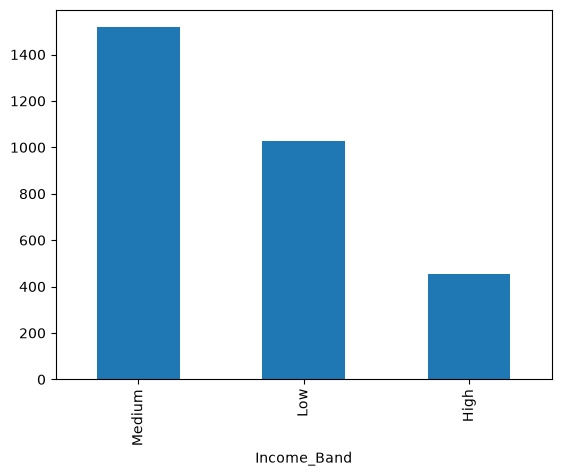

In [15]:
df['Income_Band'].value_counts().plot(kind='bar')

In [16]:
#Examine the distribution of unique categories in categorical cols:-
categorical_cols=df[['BRId','GenderId','IAId','Amount_of_Credit_Cards','Nationality','Occupation','Fee_Structure','Loyalty_Classification','Properties_Owned','Risk_Weighting','Income_Band']]
for col in categorical_cols:
    print(f'Value Counts for {col}:')
    display(df[col].value_counts())

Value Counts for BRId:


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64

Value Counts for GenderId:


GenderId
2    1512
1    1488
Name: count, dtype: int64

Value Counts for IAId:


...

Properties_Owned
2    777
1    776
3    742
0    705
Name: count, dtype: int64

Value Counts for Risk_Weighting:


Risk_Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64

Value Counts for Income_Band:


Income_Band
Medium    1517
Low       1027
High       456
Name: count, dtype: int64

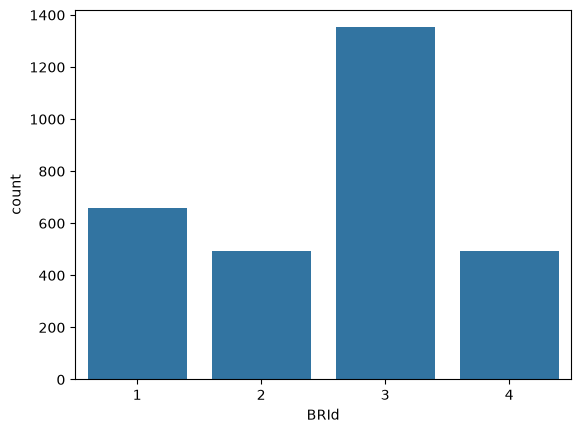

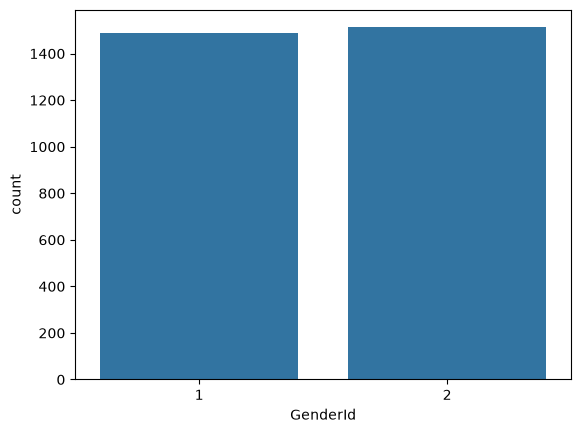

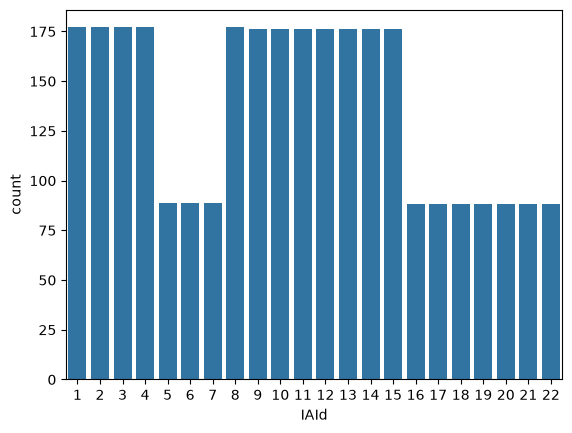

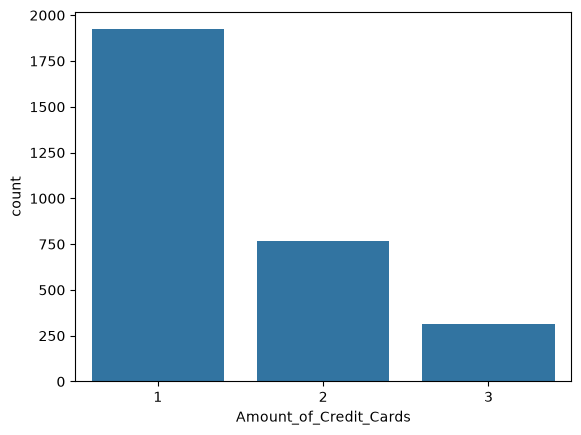

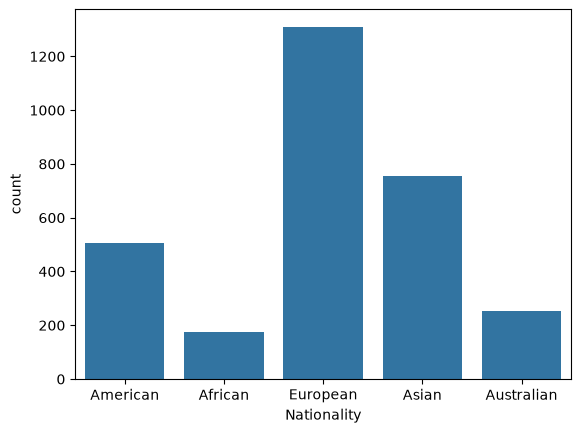

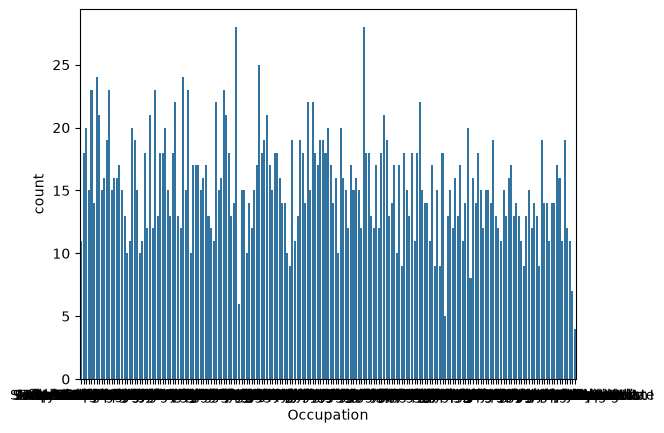

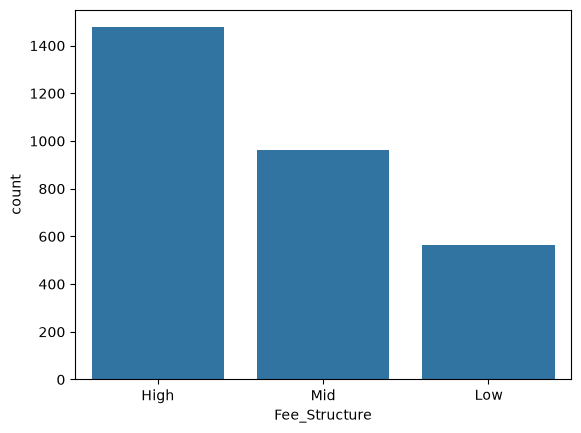

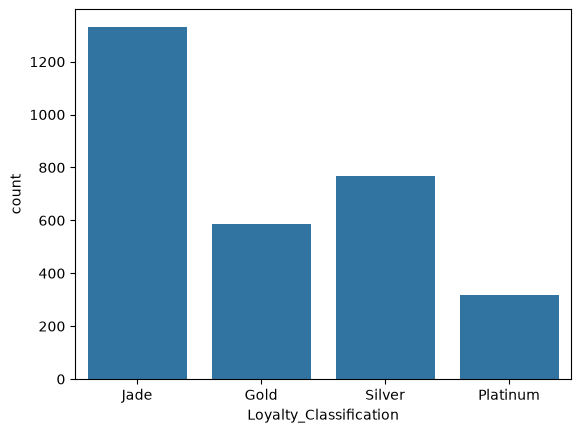

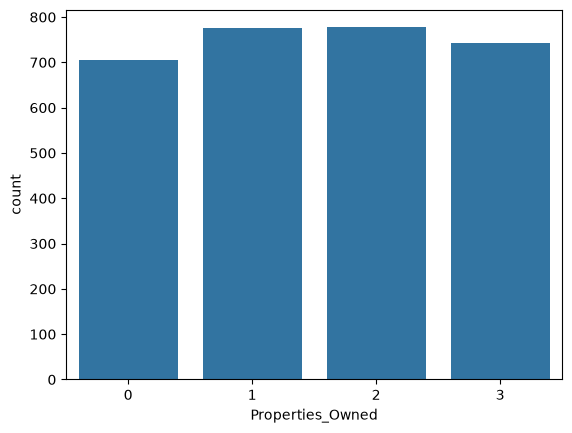

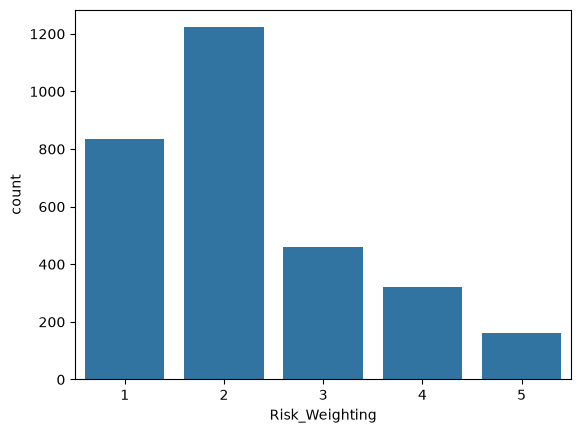

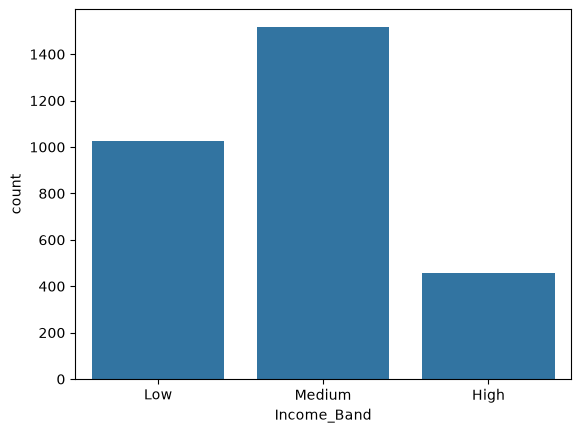

In [20]:
#Ploting the categorical cols:-
#Univariate Analysis:-
for i, predictor in enumerate(df[['BRId','GenderId','IAId','Amount_of_Credit_Cards','Nationality','Occupation','Fee_Structure','Loyalty_Classification','Properties_Owned','Risk_Weighting','Income_Band']]):
    plt.figure(i)
    sns.countplot(data=df,x=predictor)

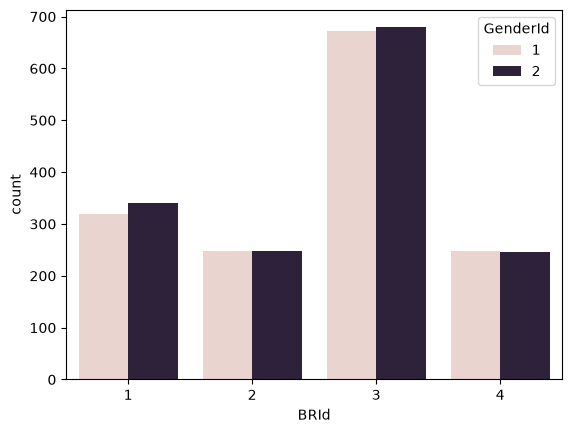

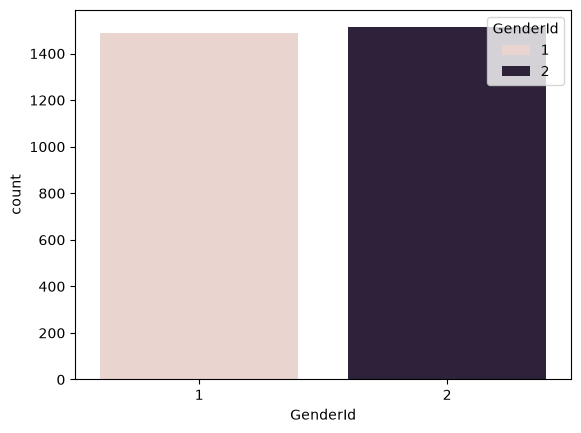

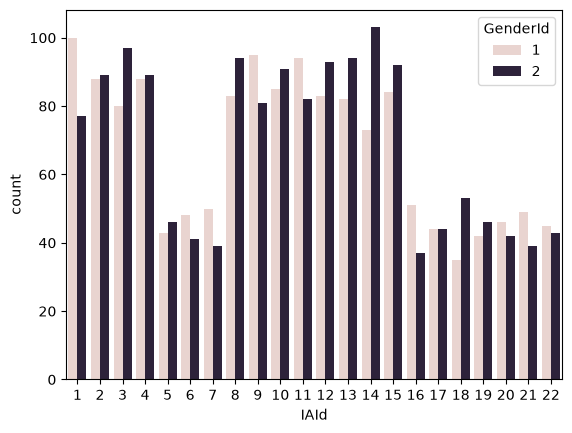

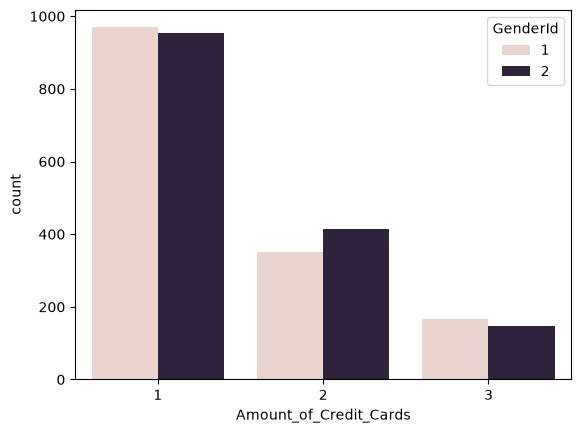

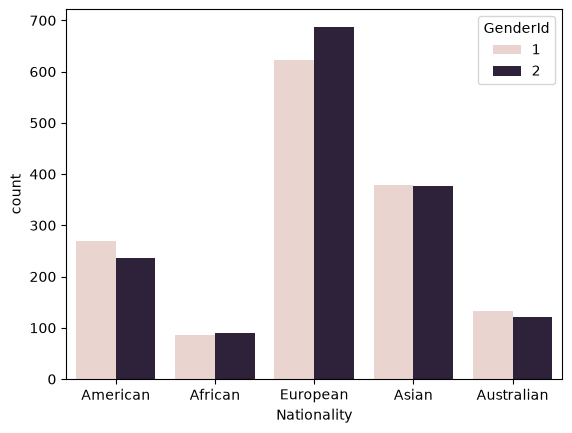

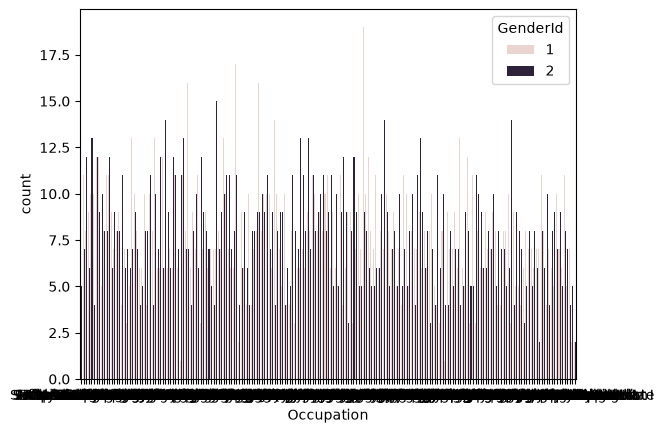

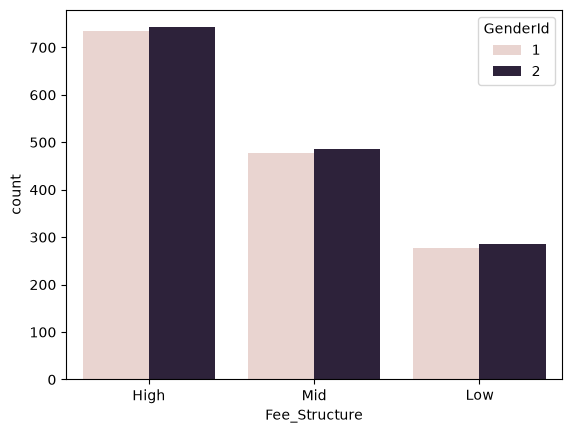

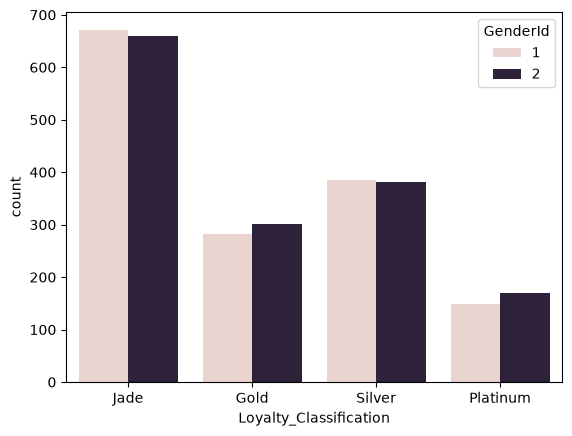

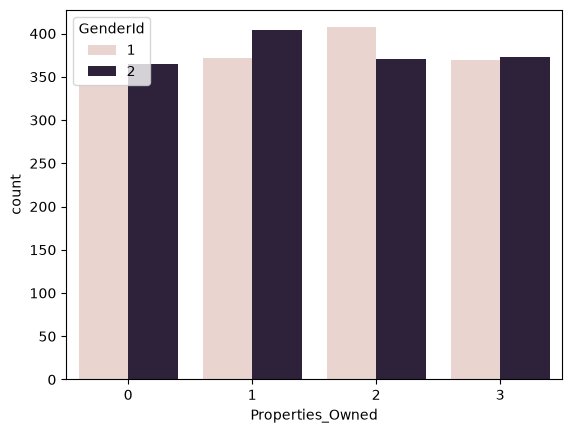

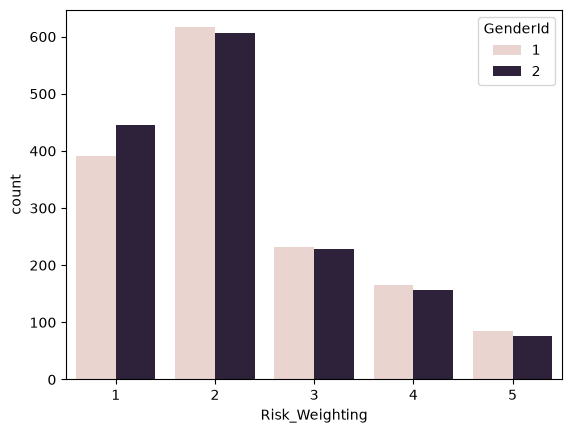

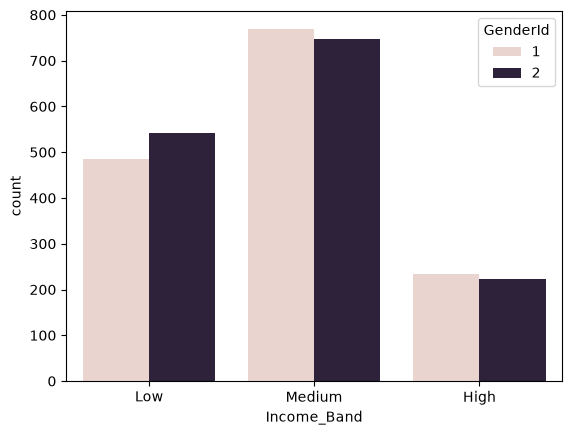

In [21]:
#Bivariate Analysis:-
for i, predictor in enumerate(df[['BRId','GenderId','IAId','Amount_of_Credit_Cards','Nationality','Occupation','Fee_Structure','Loyalty_Classification','Properties_Owned','Risk_Weighting','Income_Band']]):
    plt.figure(i)
    sns.countplot(data=df,x=predictor,hue='GenderId')

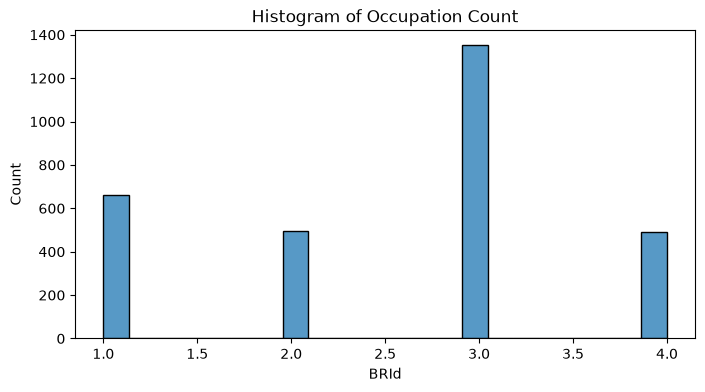

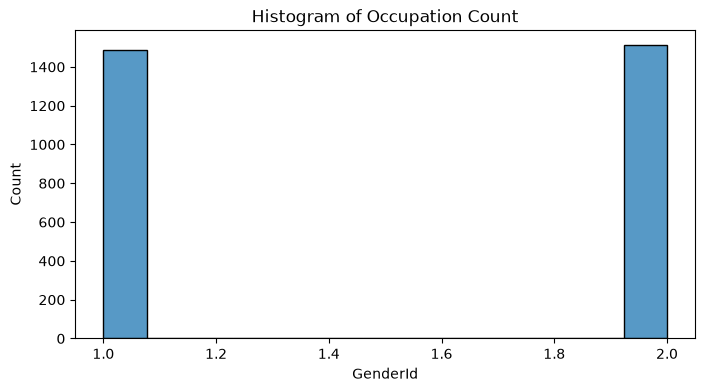

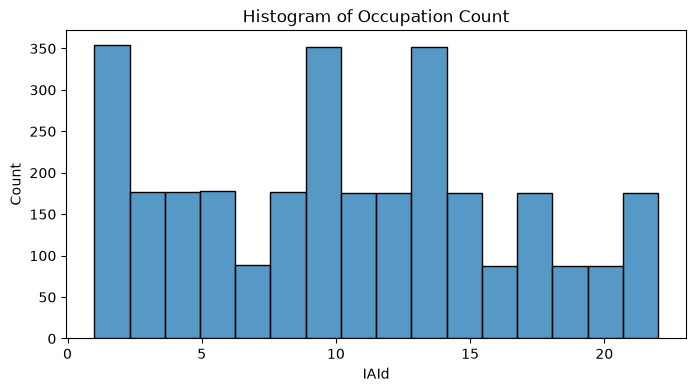

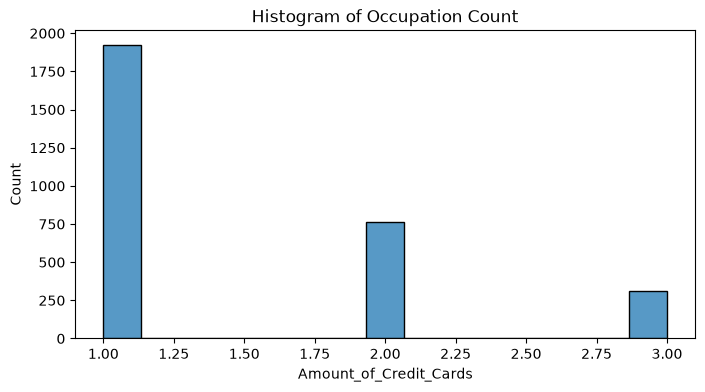

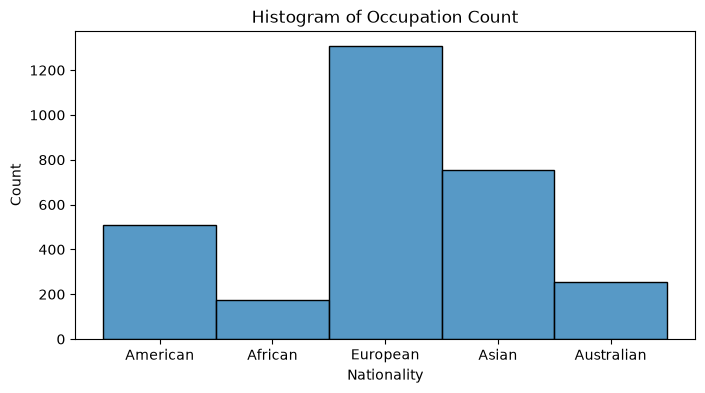

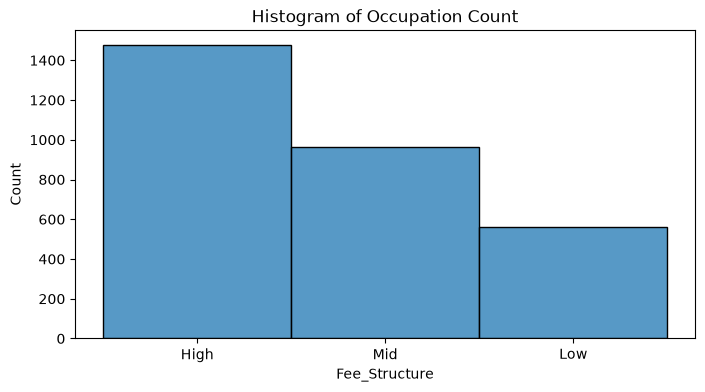

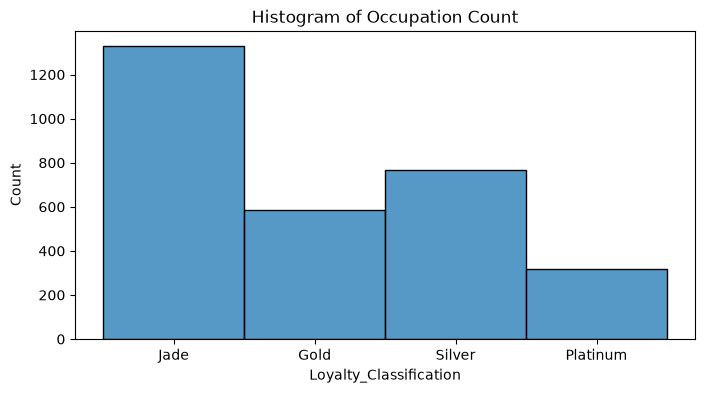

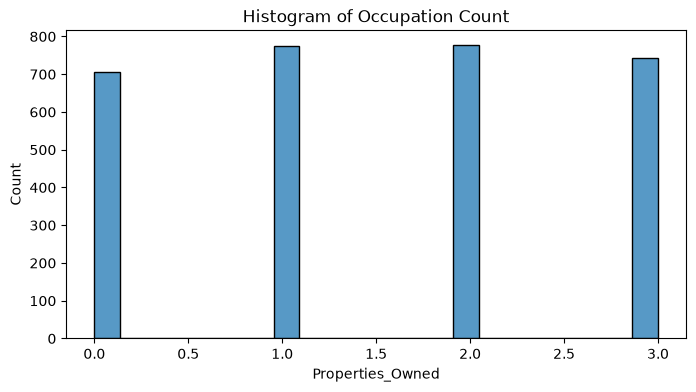

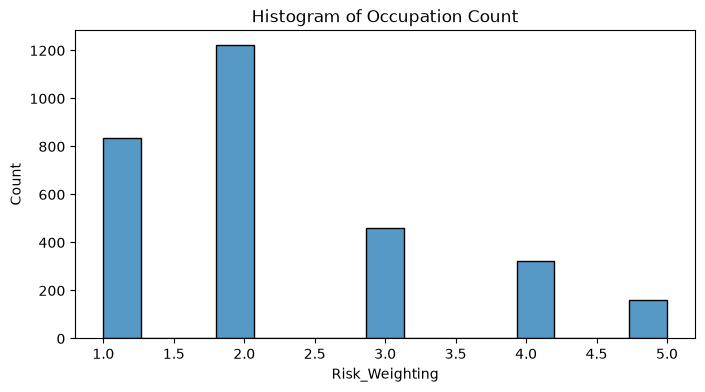

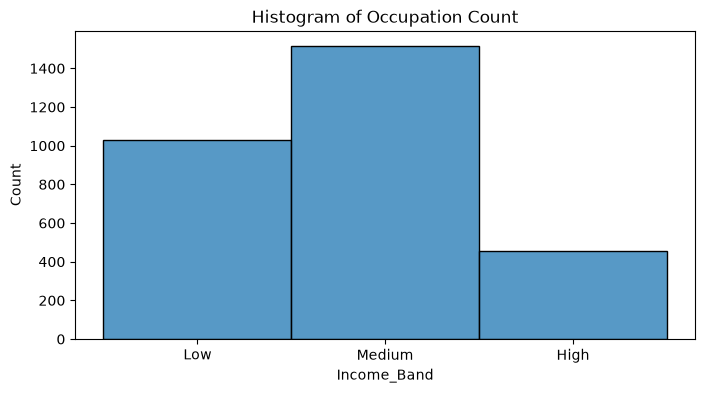

In [24]:
#Histplot of value counts for different occupation:-
for col in categorical_cols:
    if col=='Occupation':
        continue
    plt.figure(figsize=(8,4))
    sns.histplot(df[col])
    plt.title('Histogram of Occupation Count')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

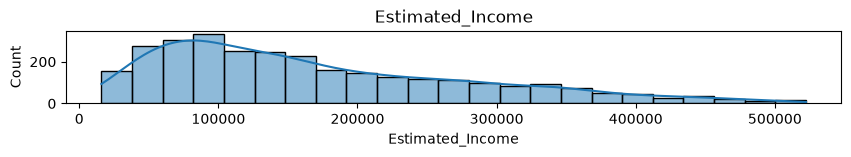

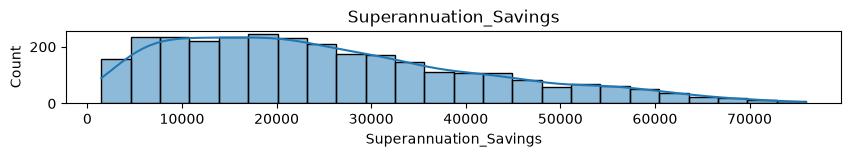

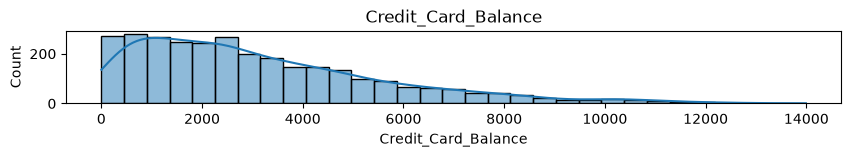

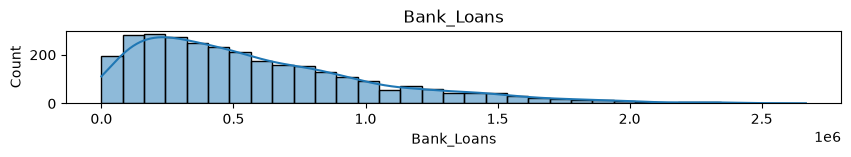

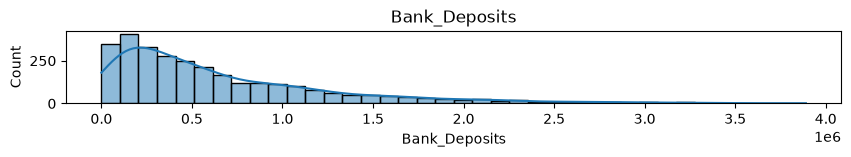

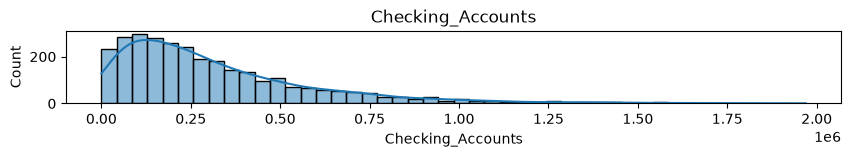

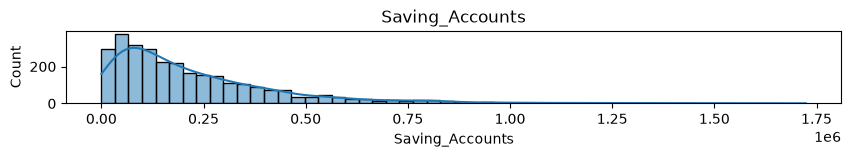

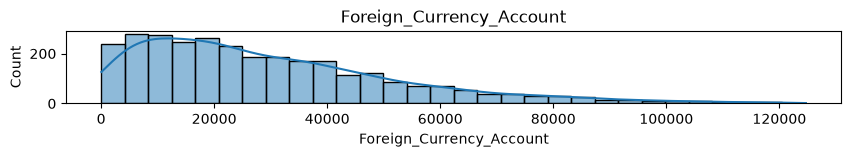

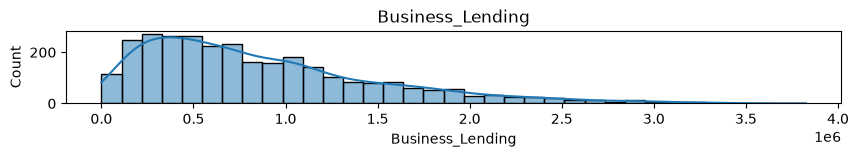

In [31]:
#Numerical Analysis:-
numerical_cols=df[['Estimated_Income','Superannuation_Savings','Credit_Card_Balance','Bank_Loans','Bank_Deposits','Checking_Accounts','Saving_Accounts','Foreign_Currency_Account','Business_Lending' ]]
for i,col in enumerate(numerical_cols):
    plt.figure(figsize=(10,10))
    plt.subplot(9,1,i+1)
    sns.histplot(df[col],kde=True)
    plt.title(col)
plt.show()

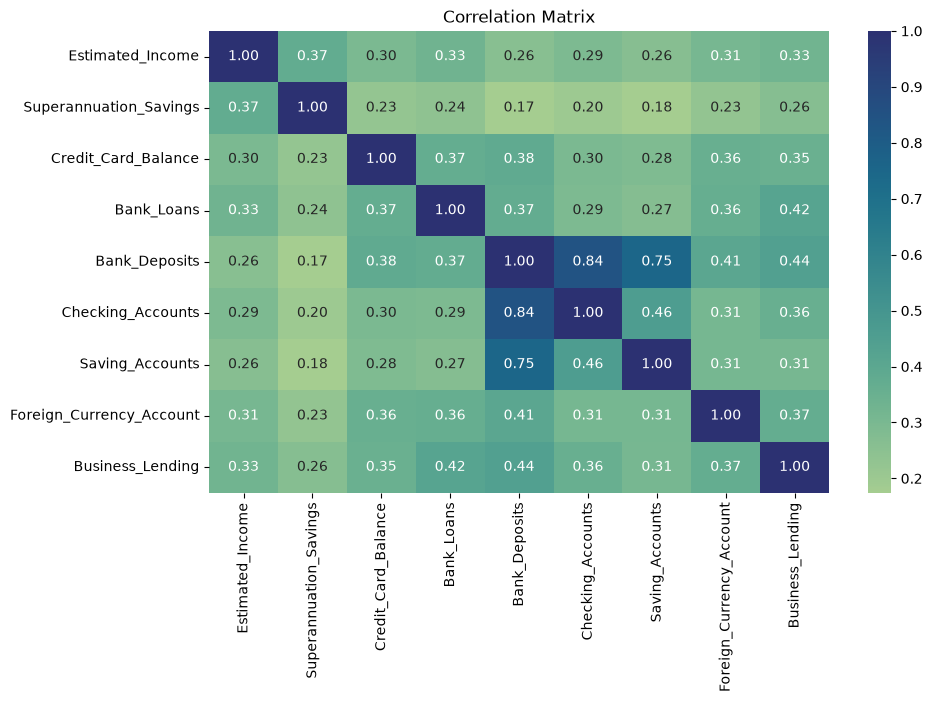

In [36]:
#Heatmaps for numerical_cols:-
numerical_cols=df[['Estimated_Income','Superannuation_Savings','Credit_Card_Balance','Bank_Loans','Bank_Deposits','Checking_Accounts','Saving_Accounts','Foreign_Currency_Account','Business_Lending' ]]
correlation_matrix=numerical_cols.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=True,cmap='crest',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Note:- GenderID includes 1(Male) and 2(Female).
# Also BRId i.e Banking Relationship includes 1(Retail), 2(Institutional), 3(Private Bank), 4(Commercial)

In [38]:
#Saving the file:-
df.to_csv("banking_clean.csv", index=False)

### Key Findings:-
1. The dataset is clean and complete, with no missing values or duplicate records, making it suitable for analysis.
2. Most numerical variables are right-skewed, indicating that the majority of customers have lower financial values, while a small proportion hold significantly higher incomes, deposits, and loan amounts.
3. Branch ID 3 serves the largest number of customers, suggesting it is one of the bank's most active branches.
4. The customer base is almost evenly distributed between male and female customers, indicating a balanced gender representation.
5. Credit Card Type 1 is the most widely used credit card product among customers.
6. Customers with European nationality form the largest customer segment in the dataset.
7. The High Fee Structure category contains the highest number of customers, indicating a preference for premium banking products.
8. Jade is the most common loyalty classification, followed by Silver, showing strong participation in the bank's loyalty program.
9. Most customers own one or two properties, indicating moderate asset ownership.
10. Risk Weight 2 has the highest customer count, suggesting that a large proportion of customers fall into the moderate-risk category.
11. The Medium Income Band contains the highest number of customers, showing that the bank primarily serves middle-income individuals.

### Correlation Findings:-
1. Bank Deposits and Checking Accounts have a strong positive correlation (0.84), indicating that customers with larger deposits also tend to maintain higher checking account balances.
2. Bank Deposits and Saving Accounts show a strong positive correlation (0.75), suggesting that customers who actively save also maintain higher overall deposits.
3. Estimated Income is positively correlated with Bank Loans and Business Lending, indicating that higher-income customers are more likely to utilize lending products.
4. Bank Loans and Business Lending exhibit a moderate positive correlation (0.42), suggesting that customers with larger personal loans also tend to use business lending services.
5. Credit Card Balance has a weak to moderate positive correlation (0.38) with Bank Deposits, indicating a mild relationship between higher deposits and increased credit card balances.

#### The exploratory data analysis indicates that the bank primarily serves medium-income, moderate-risk customers who are actively engaged with deposit-based banking products. Strong positive correlations between bank deposits, checking accounts, and saving accounts suggest that customers who maintain higher deposits are also more likely to use multiple deposit-related services. Additionally, the positive relationship between estimated income and lending products indicates that higher-income customers tend to utilize bank loans and business lending more frequently. Overall, the dataset reveals meaningful customer financial patterns that can support customer segmentation, targeted product recommendations, and data-driven business decisions.